In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('cleaned_campaign_data.csv')

# Create BETTER target variable based on multiple factors
# High performing campaign = High ROI + High CTR + High Engagement

# Normalize key metrics
df['ROI_Score'] = (df['ROI'] - df['ROI'].min()) / (df['ROI'].max() - df['ROI'].min())
df['CTR_Score'] = (df['CTR'] - df['CTR'].min()) / (df['CTR'].max() - df['CTR'].min())
df['Engagement_Score_Norm'] = (df['Engagement_Score'] - df['Engagement_Score'].min()) / (df['Engagement_Score'].max() - df['Engagement_Score'].min())

# Composite performance score (weighted)
df['Performance_Score'] = (
    0.5 * df['ROI_Score'] +
    0.3 * df['CTR_Score'] +
    0.2 * df['Engagement_Score_Norm']
)

# Top 40% = Successful campaign
threshold = df['Performance_Score'].quantile(0.60)
df['Campaign_Success'] = (df['Performance_Score'] >= threshold).astype(int)

print(f"✅ New target variable created")
print(f"Success threshold (Performance Score): {threshold:.3f}")
print(f"\nCampaign Success Distribution:")
print(df['Campaign_Success'].value_counts())
print(f"\nSuccess Rate: {df['Campaign_Success'].mean():.2%}")

# Verify it makes sense
print(f"\nAvg ROI - Successful campaigns: {df[df['Campaign_Success']==1]['ROI'].mean():.3f}")
print(f"Avg ROI - Failed campaigns: {df[df['Campaign_Success']==0]['ROI'].mean():.3f}")
print(f"\nAvg Engagement - Successful: {df[df['Campaign_Success']==1]['Engagement_Score'].mean():.3f}")
print(f"Avg Engagement - Failed: {df[df['Campaign_Success']==0]['Engagement_Score'].mean():.3f}")

✅ New target variable created
Success threshold (Performance Score): 0.613

Campaign Success Distribution:
Campaign_Success
0    180000
1    120000
Name: count, dtype: int64

Success Rate: 40.00%

Avg ROI - Successful campaigns: 5.702
Avg ROI - Failed campaigns: 1.495

Avg Engagement - Successful: 6.175
Avg Engagement - Failed: 3.165


In [19]:
# Select features
feature_cols = ['Channel_Used', 'Target_Audience', 'Campaign_Goal',
                'Customer_Segment', 'Location', 'Language',
                'Duration_Days', 'Clicks', 'Impressions',
                'Engagement_Score', 'Acquisition_Cost',
                'CTR', 'CPC', 'CPM', 'Month', 'Quarter']

target_col = 'Campaign_Success'

ml_df = df[feature_cols + [target_col]].copy()

# Encode categoricals
label_encoders = {}
categorical_cols = ['Channel_Used', 'Target_Audience', 'Campaign_Goal',
                    'Customer_Segment', 'Location', 'Language']

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    label_encoders[col] = le

print(f"✅ Features ready: {ml_df.shape}")

✅ Features ready: (300000, 17)


In [21]:
X = ml_df[feature_cols]
y = ml_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape}")
print(f"Testing Set:  {X_test.shape}")
print(f"\nClass balance in train:")
print(y_train.value_counts(normalize=True).round(3))

Training Set: (240000, 16)
Testing Set:  (60000, 16)

Class balance in train:
Campaign_Success
0    0.6
1    0.4
Name: proportion, dtype: float64


In [23]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=10,
        random_state=42, 
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy,
        'auc': auc
    }
    
    print(f"   ✅ Accuracy: {accuracy*100:.2f}%")
    print(f"   ✅ AUC Score: {auc:.4f}")


🔄 Training Logistic Regression...
   ✅ Accuracy: 71.70%
   ✅ AUC Score: 0.8038

🔄 Training Random Forest...
   ✅ Accuracy: 71.68%
   ✅ AUC Score: 0.8034

🔄 Training XGBoost...
   ✅ Accuracy: 71.55%
   ✅ AUC Score: 0.8024



📊 MODEL COMPARISON
Model                       Accuracy    AUC Score
-------------------------------------------------------
Logistic Regression           0.7170       0.8038 🏆
Random Forest                 0.7168       0.8034
XGBoost                       0.7155       0.8024

📊 XGBoost Detailed Classification Report:
                  precision    recall  f1-score   support

 Low Performance       0.78      0.74      0.76     36000
High Performance       0.63      0.68      0.66     24000

        accuracy                           0.72     60000
       macro avg       0.71      0.71      0.71     60000
    weighted avg       0.72      0.72      0.72     60000



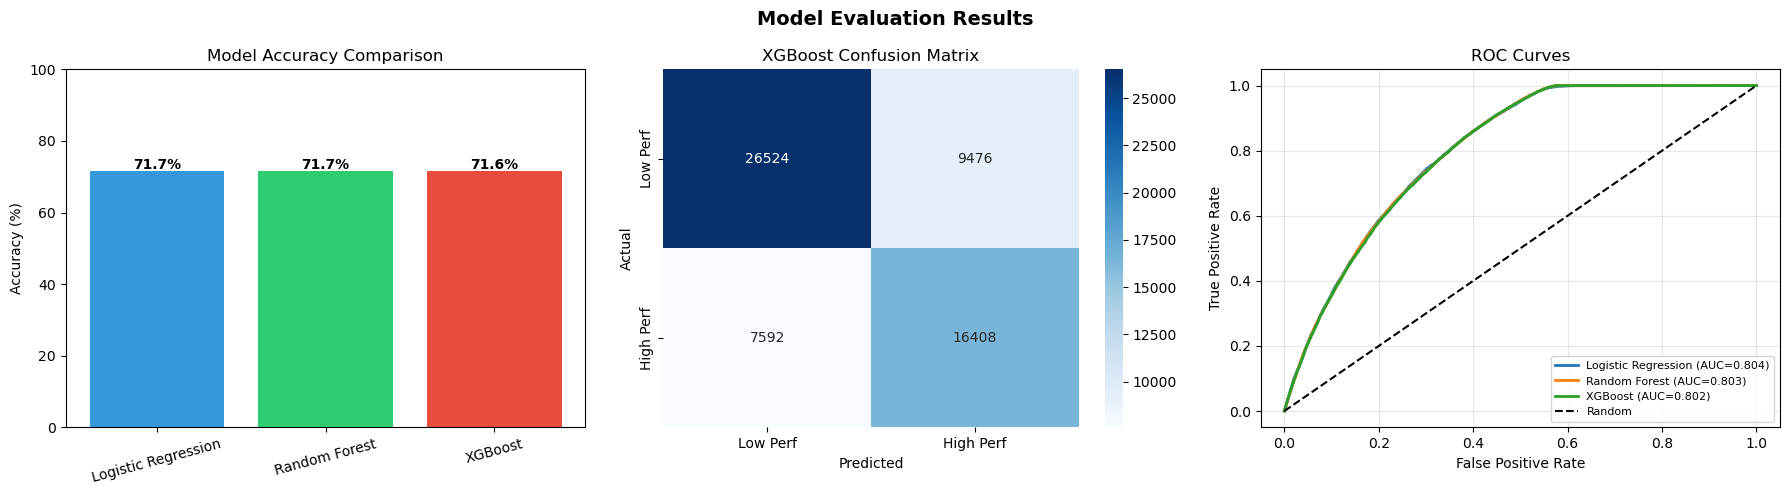

In [25]:
# Model comparison table
print("\n" + "="*55)
print("📊 MODEL COMPARISON")
print("="*55)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC Score':>12}")
print("-"*55)

best_model_name = max(results, key=lambda x: results[x]['auc'])

for name, result in results.items():
    marker = " 🏆" if name == best_model_name else ""
    print(f"{name:<25} {result['accuracy']:>10.4f} {result['auc']:>12.4f}{marker}")

print("="*55)

# Detailed XGBoost report
print(f"\n📊 XGBoost Detailed Classification Report:")
print(classification_report(y_test, results['XGBoost']['y_pred'],
                             target_names=['Low Performance', 'High Performance']))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation Results', fontsize=14, fontweight='bold')

# Plot 1 - Accuracy comparison
model_names = list(results.keys())
accuracies = [r['accuracy']*100 for r in results.values()]
axes[0].bar(model_names, accuracies, 
            color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2 - Confusion Matrix
cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Perf', 'High Perf'],
            yticklabels=['Low Perf', 'High Perf'],
            ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Plot 3 - ROC Curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    axes[2].plot(fpr, tpr,
                 label=f"{name} (AUC={result['auc']:.3f})",
                 linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', label='Random')
axes[2].set_title('ROC Curves')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

🎯 Top Features Driving Campaign Success:
         Feature  Importance
             CPC    0.525602
             CPM    0.176809
Engagement_Score    0.136298
             CTR    0.035275
          Clicks    0.018738
     Impressions    0.017935
Acquisition_Cost    0.014984
    Channel_Used    0.013101
   Duration_Days    0.008410
 Target_Audience    0.008020
        Language    0.007753
        Location    0.007581
           Month    0.007483
   Campaign_Goal    0.007353
Customer_Segment    0.007353
         Quarter    0.007304


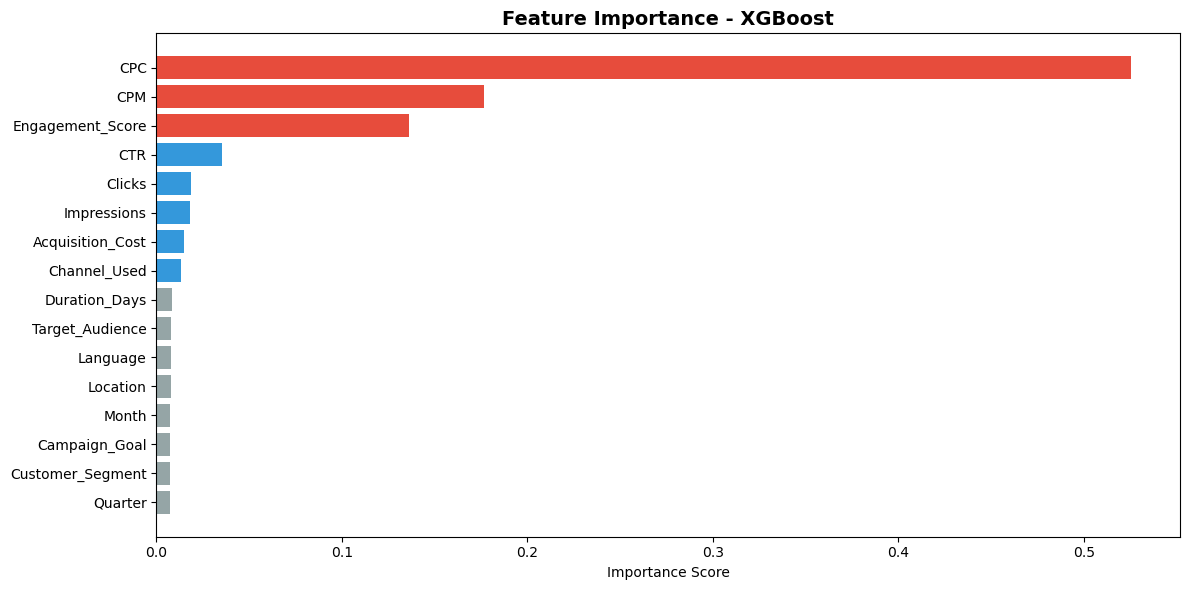

In [27]:
# Feature importance from XGBoost
xgb_model = results['XGBoost']['model']

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🎯 Top Features Driving Campaign Success:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 8 
          else '#95a5a6' for i in range(len(feature_importance))]
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color=colors)
plt.title('Feature Importance - XGBoost', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import pickle

with open('xgb_campaign_model.pkl', 'wb') as f:
    pickle.dump(results['XGBoost']['model'], f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("✅ Model saved")
print(f"\n🏆 FINAL MODEL SUMMARY")
print("="*50)
print(f"Model: XGBoost Classifier")
print(f"Training Samples: {X_train.shape[0]:,}")
print(f"Testing Samples: {X_test.shape[0]:,}")
print(f"Features Used: {len(feature_cols)}")
print(f"Best Accuracy: {results['XGBoost']['accuracy']*100:.2f}%")
print(f"AUC Score: {results['XGBoost']['auc']:.4f}")
print("="*50)

✅ Model saved

🏆 FINAL MODEL SUMMARY
Model: XGBoost Classifier
Training Samples: 240,000
Testing Samples: 60,000
Features Used: 16
Best Accuracy: 71.55%
AUC Score: 0.8024


In [31]:
import pandas as pd
import numpy as np
import pickle

# Load cleaned data
df = pd.read_csv('cleaned_campaign_data.csv')

# Recreate Performance Score and Campaign Success
df['ROI_Score'] = (df['ROI'] - df['ROI'].min()) / (df['ROI'].max() - df['ROI'].min())
df['CTR_Score'] = (df['CTR'] - df['CTR'].min()) / (df['CTR'].max() - df['CTR'].min())
df['Engagement_Score_Norm'] = (df['Engagement_Score'] - df['Engagement_Score'].min()) / (df['Engagement_Score'].max() - df['Engagement_Score'].min())

df['Performance_Score'] = (
    0.5 * df['ROI_Score'] +
    0.3 * df['CTR_Score'] +
    0.2 * df['Engagement_Score_Norm']
)

threshold = df['Performance_Score'].quantile(0.60)
df['Campaign_Success'] = (df['Performance_Score'] >= threshold).astype(int)

# Load model and add predictions
with open('xgb_campaign_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

feature_cols = ['Channel_Used', 'Target_Audience', 'Campaign_Goal',
                'Customer_Segment', 'Location', 'Language',
                'Duration_Days', 'Clicks', 'Impressions',
                'Engagement_Score', 'Acquisition_Cost',
                'CTR', 'CPC', 'CPM', 'Month', 'Quarter']

ml_df = df[feature_cols].copy()
categorical_cols = ['Channel_Used', 'Target_Audience', 'Campaign_Goal',
                    'Customer_Segment', 'Location', 'Language']

for col in categorical_cols:
    ml_df[col] = label_encoders[col].transform(ml_df[col].astype(str))

df['Predicted_Success'] = model.predict(ml_df)
df['Success_Probability'] = model.predict_proba(ml_df)[:, 1]

# ---- Generate all 4 summary files ----

# 1. Channel Summary
channel_summary = df.groupby('Channel_Used').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_CTR=('CTR', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Avg_Engagement=('Engagement_Score', 'mean'),
    Success_Rate=('Campaign_Success', 'mean'),
    Avg_Success_Probability=('Success_Probability', 'mean')
).round(3).reset_index()
channel_summary.to_csv('powerbi_channel_summary.csv', index=False)
print("✅ powerbi_channel_summary.csv")

# 2. Monthly Summary
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_summary = df.groupby('Month').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Success_Rate=('Campaign_Success', 'mean')
).round(3).reset_index()
monthly_summary['Month_Name'] = monthly_summary['Month'].map(month_names)
monthly_summary.to_csv('powerbi_monthly_summary.csv', index=False)
print("✅ powerbi_monthly_summary.csv")

# 3. Audience Summary
audience_summary = df.groupby('Target_Audience').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_CTR=('CTR', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Success_Rate=('Campaign_Success', 'mean')
).round(3).reset_index()
audience_summary.to_csv('powerbi_audience_summary.csv', index=False)
print("✅ powerbi_audience_summary.csv")

# 4. Goal Summary
goal_summary = df.groupby('Campaign_Goal').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_CTR=('CTR', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Success_Rate=('Campaign_Success', 'mean')
).round(3).reset_index()
goal_summary.to_csv('powerbi_goal_summary.csv', index=False)
print("✅ powerbi_goal_summary.csv")

# 5. Main data with predictions (smaller sample for Power BI performance)
df.sample(50000, random_state=42).to_csv('powerbi_main_data.csv', index=False)
print("✅ powerbi_main_data.csv")

print("\n🎉 All 5 files generated successfully!")
print("Now download all files from Jupyter and open Power BI Desktop")

✅ powerbi_channel_summary.csv
✅ powerbi_monthly_summary.csv
✅ powerbi_audience_summary.csv
✅ powerbi_goal_summary.csv
✅ powerbi_main_data.csv

🎉 All 5 files generated successfully!
Now download all files from Jupyter and open Power BI Desktop
